# Daily data functionality

This notebook prepares day-level client order views from the cleaned orders dataset.

In [1]:
import pandas as pd

csv_path = "../../data/custom/orders.csv"
raw_csv_path = "../../data/csv/Hackaton/Detalle_entrega.csv"
df = pd.read_csv(csv_path)

transport_col = "transport_id"
client_col = "client"
date_col = "date"
amount_col = "amount"
item_col = "item"
item_description_col = "item_description"
unit_col = "unit"

required_columns = {
    transport_col,
    client_col,
    date_col,
    amount_col,
    item_col,
    item_description_col,
    unit_col,
}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns in cleaned dataset: {sorted(missing_columns)}")

# Recover route-level client identity from raw data only if needed.
unique_clients_per_transport = df.groupby(transport_col)[client_col].nunique(dropna=True)
needs_client_recovery = (
    not unique_clients_per_transport.empty
    and unique_clients_per_transport.max() <= 1
)

if needs_client_recovery:
    raw_columns = [
        "FECHA",
        "Transporte",
        "Destinatario mcía.",
        "Nombre 1",
        "Material",
        "Cantidad entrega",
        "Un.medida venta",
    ]
    raw_df = pd.read_csv(raw_csv_path, usecols=raw_columns).rename(
        columns={
            "FECHA": date_col,
            "Transporte": transport_col,
            "Destinatario mcía.": "client_id",
            "Nombre 1": "client_name",
            "Material": item_col,
            "Cantidad entrega": amount_col,
            "Un.medida venta": unit_col,
        }
    )

    raw_df[unit_col] = raw_df[unit_col].astype(str).str.strip().str.lower()
    raw_df[amount_col] = pd.to_numeric(raw_df[amount_col], errors="coerce")
    raw_df = raw_df[raw_df[amount_col].notna()].copy()

    df[amount_col] = pd.to_numeric(df[amount_col], errors="coerce")

    merge_cols = [date_col, transport_col, item_col, amount_col, unit_col]
    for col in [date_col, transport_col, item_col, unit_col]:
        df[col] = df[col].astype(str).str.strip()
        raw_df[col] = raw_df[col].astype(str).str.strip()

    df["_match_seq"] = df.groupby(merge_cols).cumcount()
    raw_df["_match_seq"] = raw_df.groupby(merge_cols).cumcount()

    df = df.merge(
        raw_df[merge_cols + ["_match_seq", "client_id", "client_name"]],
        on=merge_cols + ["_match_seq"],
        how="left",
    )
    df = df.drop(columns=["_match_seq"])

    df["analysis_client"] = (
        df["client_name"].fillna(df["client_id"]).fillna(df[client_col]).astype(str).str.strip()
    )
else:
    df["analysis_client"] = df[client_col].astype(str).str.strip()

client_col = "analysis_client"
print("Dataset loaded.")

Dataset loaded.


In [2]:
# Split orders by day so each client appears once per day,
# with linked ordered items.

df_daily = df.copy()
df_daily["order_date"] = pd.to_datetime(
    df_daily[date_col], errors="coerce", dayfirst=True
).dt.date
df_daily["client_name"] = df_daily[client_col].astype(str).str.strip()
df_daily["quantity"] = pd.to_numeric(df_daily[amount_col], errors="coerce").fillna(0)

# Keep optional route and delivery identifiers only if they exist.
route_col = "route_id" if "route_id" in df_daily.columns else None
delivery_col = "delivery_id" if "delivery_id" in df_daily.columns else None

# Build per-line order payload to keep item-level linkage.
df_daily["ordered_item"] = df_daily.apply(
    lambda r: {
        "material": str(r.get(item_col, "")),
        "description": str(r.get(item_description_col, "")),
        "quantity": float(r.get("quantity", 0)),
        "unit": str(r.get(unit_col, "")),
    },
    axis=1,
)

aggregations = {
    "transport_ids": (transport_col, lambda s: sorted(set(s.dropna().astype(str)))),
    "total_lines": ("ordered_item", "size"),
    "total_quantity": ("quantity", "sum"),
    "ordered_items": ("ordered_item", list),
}

if route_col:
    aggregations["route_ids"] = (route_col, lambda s: sorted(set(s.dropna().astype(str))))
if delivery_col:
    aggregations["delivery_ids"] = (delivery_col, lambda s: sorted(set(s.dropna().astype(str))))

# One row per (day, client) with linked ordered items.
daily_client_orders = (
    df_daily.groupby(["order_date", "client_name"], as_index=False)
    .agg(**aggregations)
    .sort_values(["order_date", "client_name"])
    .reset_index(drop=True)
)

# Optional flat view: same grain (day, client, product) with summed quantity.
daily_client_items = (
    df_daily.groupby(
        ["order_date", "client_name", item_col, item_description_col, unit_col],
        as_index=False,
    )["quantity"]
    .sum()
    .rename(
        columns={
            item_col: "material",
            item_description_col: "description",
            unit_col: "unit",
            "quantity": "total_quantity",
        }
    )
    .sort_values(["order_date", "client_name", "description"])
    .reset_index(drop=True)
)

print("Rows in daily_client_orders (one row per day-client):", len(daily_client_orders))
print("Rows in daily_client_items (day-client-product):", len(daily_client_items))

daily_client_orders.head()

Rows in daily_client_orders (one row per day-client): 7816
Rows in daily_client_items (day-client-product): 65298


,order_date,client_name,transport_ids,total_lines,total_quantity,ordered_items
0,2026-01-30,AKI MISMO,[11420415],74,231,"[{'material': 'ED13', 'description': 'ESTRELLA..."
1,2026-01-30,ALORA,[11420416],15,25,"[{'material': 'ED13', 'description': 'ESTRELLA..."
2,2026-01-30,ASSOCIACIO CULTURAL SAGALS D'OSONA,[11420393],15,86,"[{'material': 'FD13', 'description': 'FREE DAM..."
3,2026-01-30,AUTENTIK'S,[11420324],1,50,"[{'material': '0LM2484', 'description': 'COMBO..."
4,2026-01-30,BAR 28,[11420414],3,3,"[{'material': 'NTL13LT6', 'description': 'NEST..."


In [3]:
# Optional exports
daily_client_orders.to_csv("daily_client_orders.csv", index=False)
daily_client_items.to_csv("daily_client_items.csv", index=False)
print("Exported daily_client_orders.csv and daily_client_items.csv")

Exported daily_client_orders.csv and daily_client_items.csv


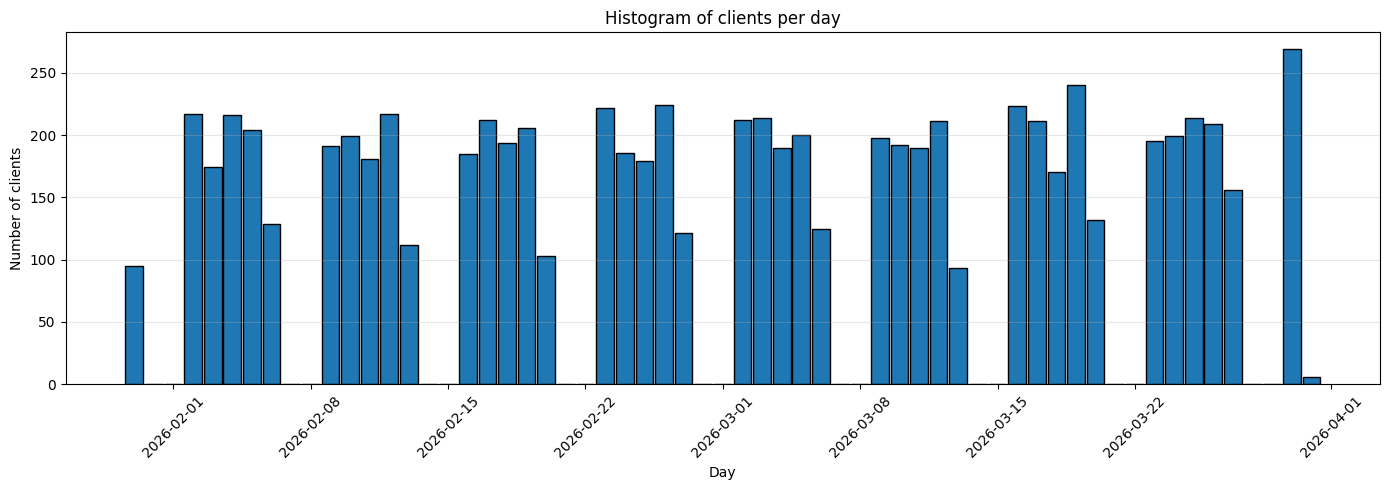

,order_date,clients_count
count,61,61.000000
mean,2026-03-01 00:00:00,128.131148
min,2026-01-30 00:00:00,0.000000
25%,2026-02-14 00:00:00,0.000000
50%,2026-03-01 00:00:00,179.000000
75%,2026-03-16 00:00:00,206.000000
max,2026-03-31 00:00:00,269.000000
std,NaN,92.979115


In [7]:
import matplotlib.pyplot as plt

# Number of clients for each day (including missing days as 0).
clients_per_day = (
    daily_client_orders.groupby("order_date")["client_name"]
    .nunique()
    .rename("clients_count")
    .reset_index()
)

clients_per_day["order_date"] = pd.to_datetime(clients_per_day["order_date"])
all_days = pd.DataFrame(
    {
        "order_date": pd.date_range(
            start=clients_per_day["order_date"].min(),
            end=clients_per_day["order_date"].max(),
            freq="D",
        )
    }
)
clients_per_day = (
    all_days.merge(clients_per_day, on="order_date", how="left")
    .fillna({"clients_count": 0})
    .sort_values("order_date")
)
clients_per_day["clients_count"] = clients_per_day["clients_count"].astype(int)

plt.figure(figsize=(14, 5))
plt.bar(clients_per_day["order_date"], clients_per_day["clients_count"], width=0.9, edgecolor="black")
plt.title("Histogram of clients per day")
plt.xlabel("Day")
plt.ylabel("Number of clients")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

clients_per_day.describe()